L=15: S=8.367, simple=15.920
L=20: S=9.078, simple=17.929
L=25: S=9.853, simple=19.922
L=30: S=10.137, simple=21.073
L=35: S=10.543, simple=22.469
L=40: S=10.694, simple=23.267
L=45: S=10.961, simple=24.304
L=50: S=11.042, simple=24.899
Saved: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_c/plot_d_simple_mean_vs_entropy_L15-50.png


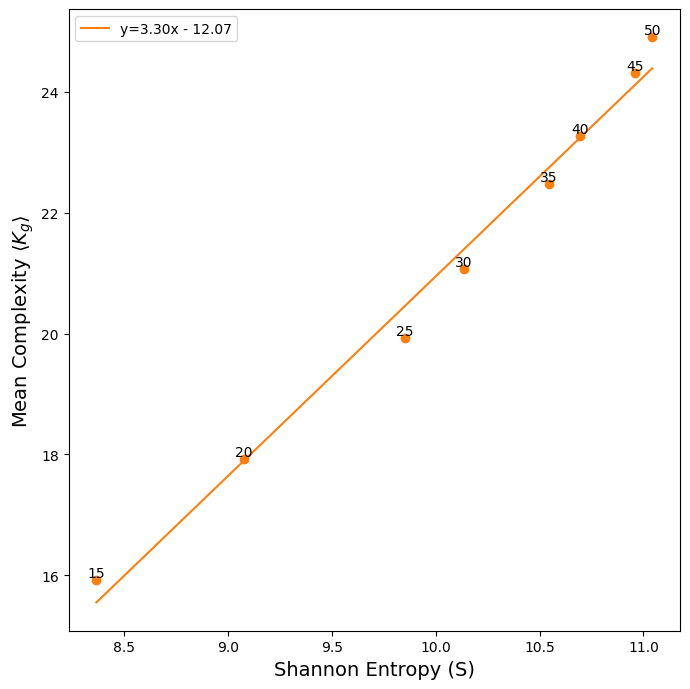

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ===================================
# Paths and settings
# ===================================

base_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_c/plot_c_files/plot_d")
output_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_c")

min_L, max_L = 15, 50

# ===================================
# Helper function
# ===================================

def read_float(path):
    return float(path.read_text().strip())

def make_plot(x, y, labels):
    m, b = np.polyfit(x, y, 1)
    fit_line = m * x + b
    sign = "-" if b < 0 else "+"
    label = f'y={m:.2f}x {sign} {abs(b):.2f}'
    plt.figure(figsize=(7, 7))
    plt.scatter(x, y, color='tab:orange')
    plt.plot(x, fit_line, color='orange', label=label)

    for xi, yi, lbl in zip(x, y, labels):
        plt.text(xi, yi, lbl, fontsize=10, ha='center', va='bottom')

    plt.xlabel("Shannon Entropy (S)", fontsize=14)
    plt.ylabel(r"Mean Complexity $\langle K_g \rangle$", fontsize=14)
    #plt.title(f"Kg vs Shannon Entropy (L={min_L}-{max_L})", fontsize=15)
    plt.legend()
    plt.tight_layout()

    out_path = output_dir / f"plot_d_simple_mean_vs_entropy_L{min_L}-{max_L}.png"
    plt.savefig(out_path, dpi=300)
    print(f"Saved: {out_path}")

    plt.show()
    plt.close()

# ===================================
# Collect data
# ===================================

entropy_vals = []
simple_means = []
labels = []

for L_dir in sorted(base_dir.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else -1):
    if not (L_dir.is_dir() and L_dir.name.isdigit()):
        continue

    L = int(L_dir.name)
    if not (min_L <= L <= max_L):
        continue

    try:
        entropy = read_float(L_dir / "entropy" / f"dataset{L}_entropy_value.txt")
        simple = read_float(L_dir / "lz_values/mean/simple_mean.txt")

        entropy_vals.append(entropy)
        simple_means.append(simple)
        labels.append(str(L))

        print(f"L={L}: S={entropy:.3f}, simple={simple:.3f}")

    except Exception as e:
        print(f"Skipping L={L}: {e}")

if not entropy_vals:
    raise RuntimeError("No data found!")

entropy_vals = np.array(entropy_vals)
simple_means = np.array(simple_means)

# ===================================
# Make plot
# ===================================

make_plot(entropy_vals, simple_means, labels)